In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
plt.rcParams.update({
    "font.size": 12,              # base font size
    "axes.labelsize": 12,         # axis label size
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 2,
    "axes.linewidth": 1,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "figure.dpi": 600,
})

In [3]:
jku_blue = np.array(to_rgb("#0084BB"))
jku_red = np.array(to_rgb("#D95C4C"))
jku_green = np.array(to_rgb("#5BA755"))
jku_gray = np.array(to_rgb("#7d828c"))
jku_yellow = np.array(to_rgb("#F1BC3F"))

jadwiga_green = np.array(to_rgb("#638537"))
jadwiga_blue = np.array(to_rgb("#469dd4"))
jadwiga_dark_blue = np.array(to_rgb("#316D91"))
jadwiga_red = np.array(to_rgb("#db3932"))
jadwiga_purple = np.array(to_rgb("#853763"))
jadwiga_yellow = np.array(to_rgb("#E6B765"))

methodcolors = {
    "Noisy": jadwiga_dark_blue,
    "Projected": jadwiga_green,
    "Harmoniq": jadwiga_purple
}

def lighten_color(color, amount):
    return color + (1 - color) * amount


/var/folders/rv/7wzqqk017bx9331kt1qfw0d80000gn/T/ipykernel_9569/3787951878.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


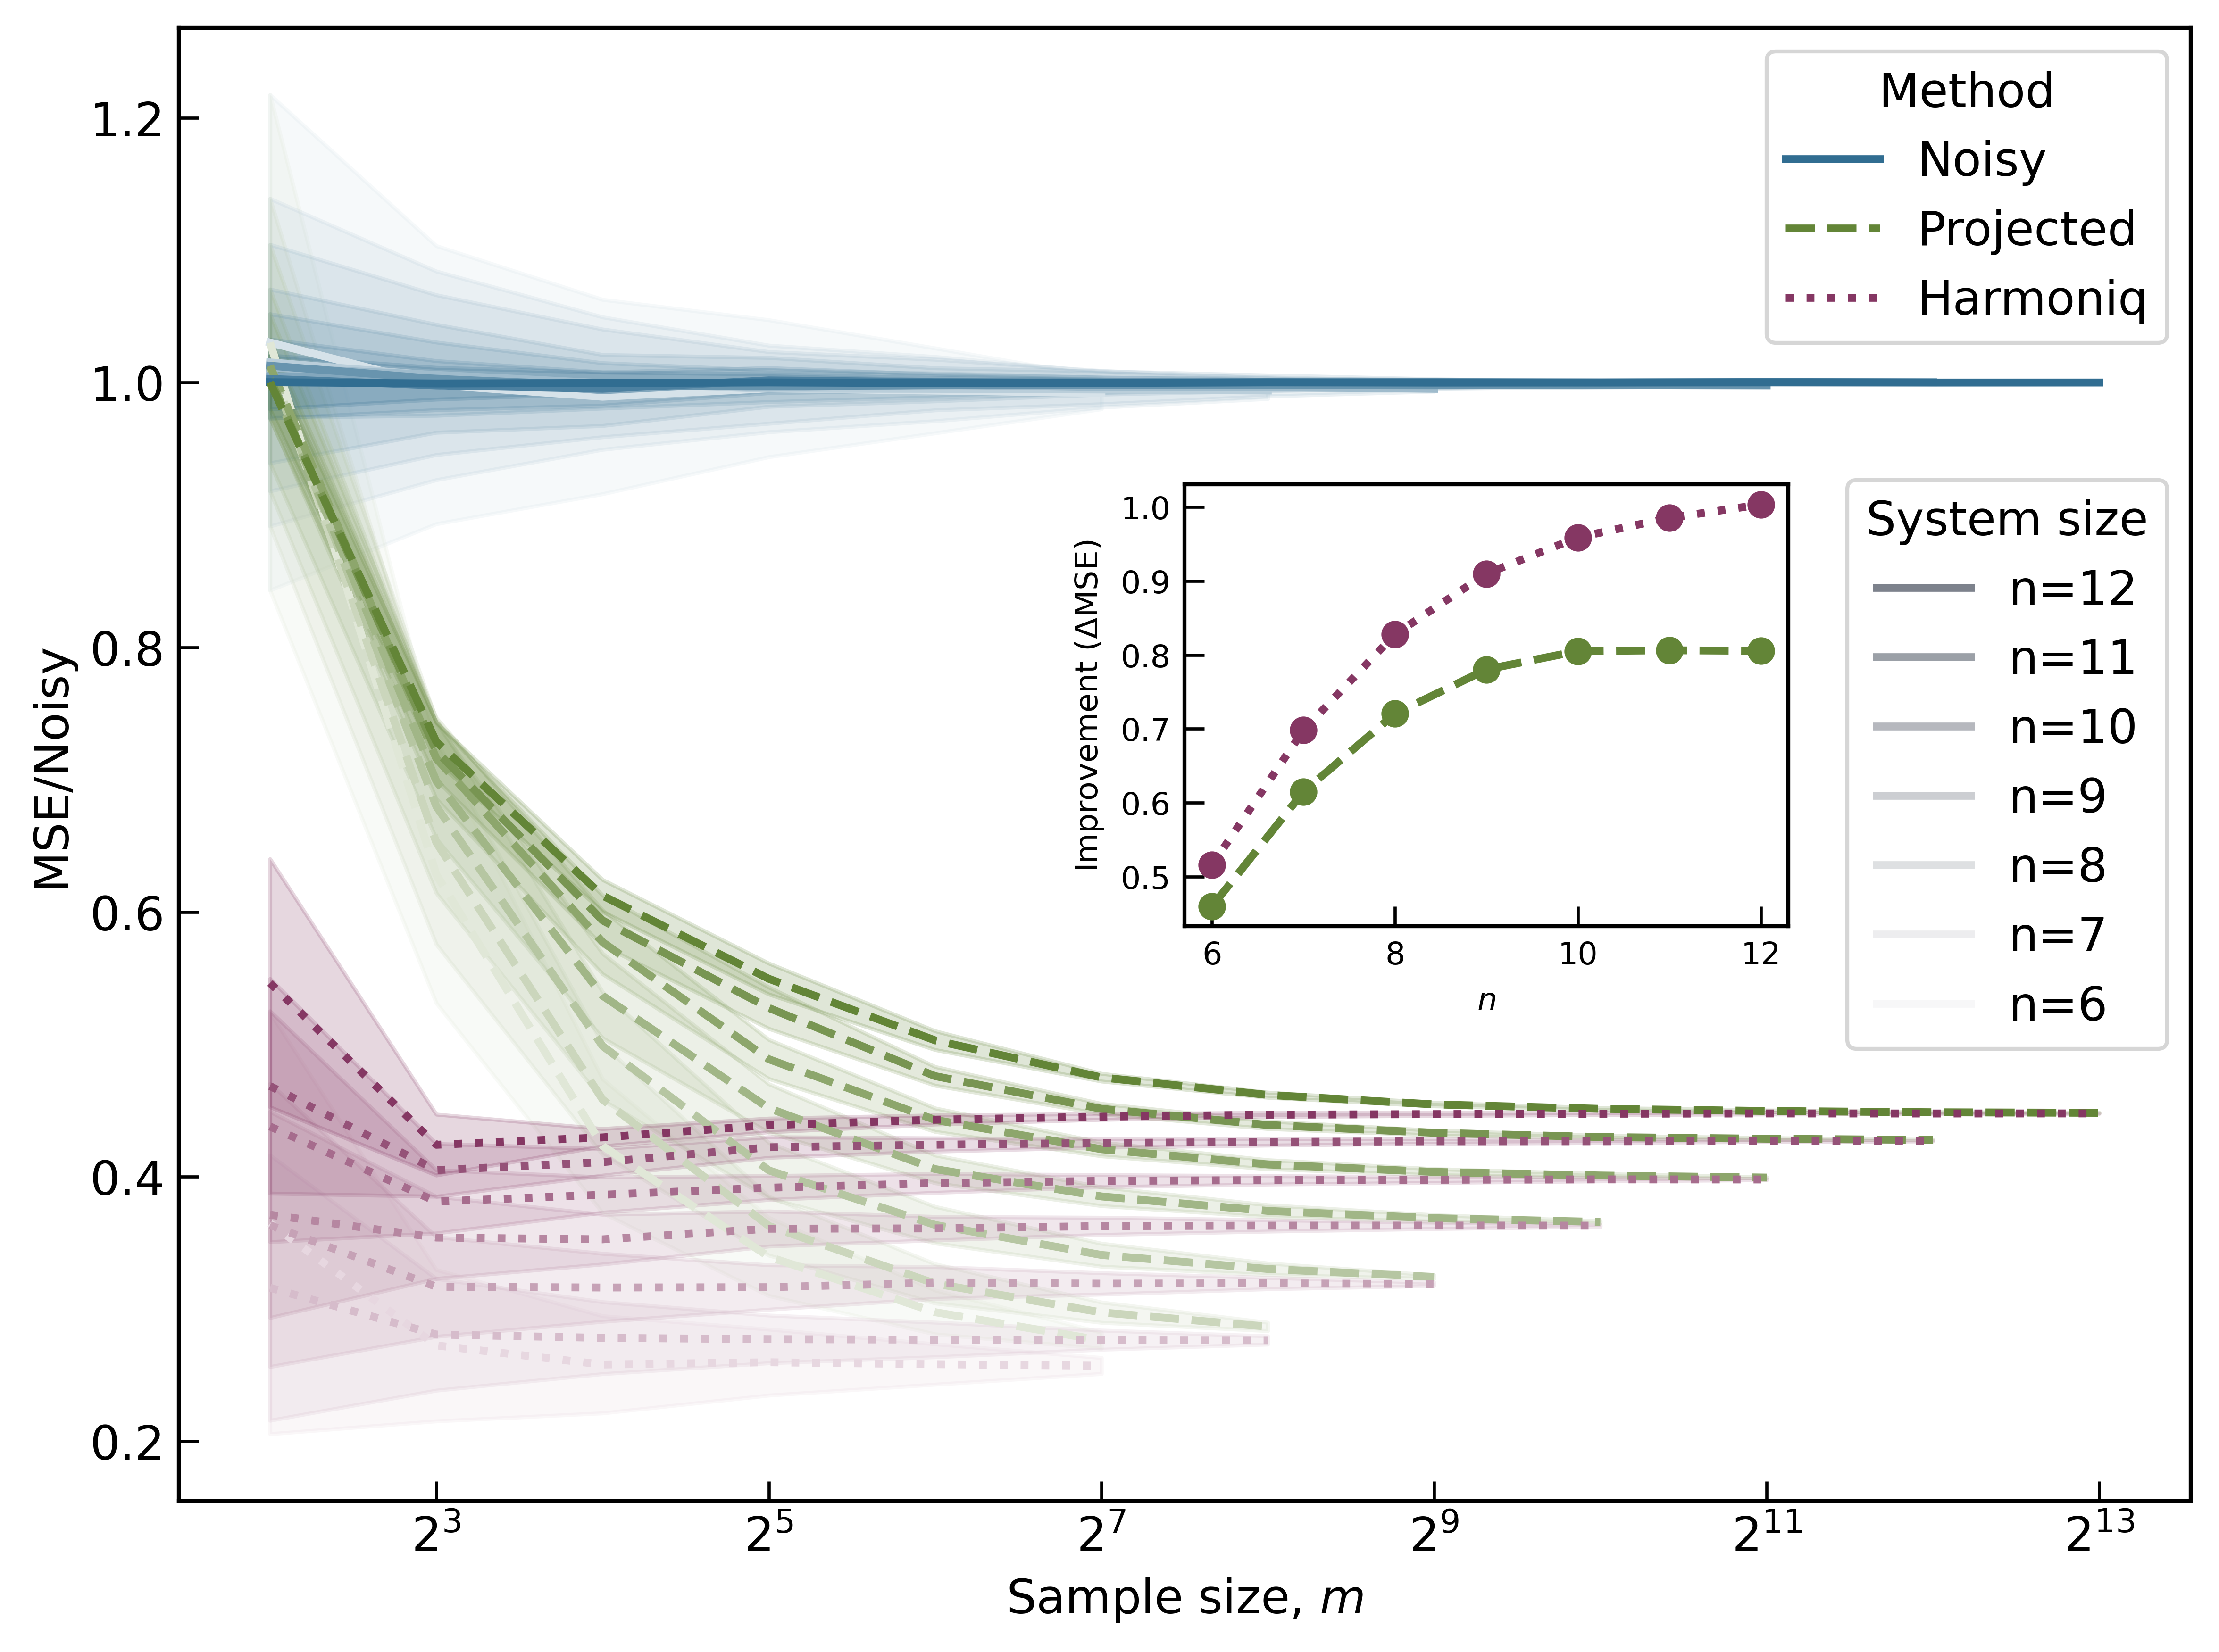

In [4]:
# Parameters
number_of_runs = 10
number_of_batches = 10
n_values = range(6, 13)
alphas = np.linspace(0.3, 1.0, len(n_values))  # lighter → darker

Noisycolors = [
    lighten_color(np.array(to_rgb(methodcolors["Noisy"])), t)
    for t in np.linspace(0, 0.8, len(alphas))
]
Projectedcolors = [
    lighten_color(np.array(to_rgb(methodcolors["Projected"])), t)
    for t in np.linspace(0, 0.8, len(alphas))
]
Harmoniqcolors = [
    lighten_color(np.array(to_rgb(methodcolors["Harmoniq"])), t)
    for t in np.linspace(0, 0.8, len(alphas))
]
colors = [
    lighten_color(jku_gray, t)
    for t in np.linspace(0, 0.8, len(alphas))
]

# --- Main figure ---
fig, ax = plt.subplots(figsize=(8,6))

for i, n in enumerate(n_values):
    if n % 2 == 1:
        size_aug = n
    else:
        size_aug = n - 1

    df = pd.read_csv(
        f"Results_10x10/Distances_n_{n}_size_aug_{size_aug}_runs_{number_of_runs}_batches_{number_of_batches}.csv"
    )

    normalization = np.mean(df["mean_distance_noisy_all"])

    mean_noisy = df["mean_distance_noisy_all"]/normalization
    std_noisy = df["std_distance_noisy_all"]/normalization

    mean_denoised = df["mean_distance_denoised_all"]/normalization
    std_denoised = df["std_distance_denoised_all"]/normalization

    mean_aug_denoised = df["mean_distance_aug_denoised_all"]/normalization
    std_aug_denoised = df["std_distance_aug_denoised_all"]/normalization

    x = 2**np.arange(2, n+2)

    # Noisy
    ax.plot(x, mean_noisy, "-", color=Noisycolors[len(n_values)-1-i])
    ax.fill_between(x, mean_noisy-std_noisy, mean_noisy+std_noisy,
                    color=Noisycolors[len(n_values)-1-i], alpha=0.2)

    # Projected
    ax.plot(x, mean_denoised, "--", color=Projectedcolors[len(n_values)-1-i])
    ax.fill_between(x, mean_denoised-std_denoised, mean_denoised+std_denoised,
                    color=Projectedcolors[len(n_values)-1-i], alpha=0.2)

    # Harmoniq
    ax.plot(x, mean_aug_denoised, ":", color=Harmoniqcolors[len(n_values)-1-i])
    ax.fill_between(x, mean_aug_denoised-std_aug_denoised, mean_aug_denoised+std_aug_denoised,
                    color=Harmoniqcolors[len(n_values)-1-i], alpha=0.2)

# Main axis formatting
ax.set_xscale('log', base=2)
ax.set_xlabel(r'Sample size, $m$')
ax.set_ylabel(r"MSE/Noisy")

# --- Inset ---

m = 3
mean_denoised_all_n = []
mean_aug_denoised_all_n = []

for i, n in enumerate(n_values):
    if n % 2 == 1:
        size_aug = n
    else:
        size_aug = n - 1

    df = pd.read_csv(
        f"Results_10x10/Distances_n_{n}_size_aug_{size_aug}_runs_{number_of_runs}_batches_{number_of_batches}.csv"
    )

    base_mse = df["mean_distance_noisy_all"][m]

    mean_denoised_all_n.append(base_mse - df["mean_distance_denoised_all"][m])
    mean_aug_denoised_all_n.append(base_mse - df["mean_distance_aug_denoised_all"][m])

# Plot inset

ax_inset = inset_axes(
    ax,
    width="30%", height="30%",
    bbox_to_anchor=(0.15, 0.04, 1, 1),
    bbox_transform=ax.transAxes,
    loc="center"
)
ax_inset.plot(n_values, mean_denoised_all_n, '--o', color=jadwiga_green)
ax_inset.plot(n_values, mean_aug_denoised_all_n, ':o', color=jadwiga_purple)
#ax_inset.fill_between(n_values, mean_arr-std_arr, mean_arr+std_arr, color=jku_gray, alpha=0.2)

ax_inset.set_xlabel(r'$n$', fontsize=8)
ax_inset.set_ylabel(r'Improvement ($\Delta$MSE)', fontsize=8)
ax_inset.tick_params(axis='both', labelsize=8)

# --- Legends ---
custom_lines = [
    Line2D([0], [0], color=methodcolors["Noisy"], lw=2, linestyle='-'),
    Line2D([0], [0], color=methodcolors["Projected"], lw=2, linestyle='--'),
    Line2D([0], [0], color=methodcolors["Harmoniq"], lw=2, linestyle=':')
]

legend1 = ax.legend(custom_lines,
                    ["Noisy", "Projected", "Harmoniq"],
                    title="Method",
                    loc="upper right")

ax.add_artist(legend1)

alpha_lines = [
    Line2D([0], [0], color=c, lw=2, alpha=a)
    for c, a in zip(colors, alphas[::-1])
]

ax.legend(alpha_lines,
          [f"n={n}" for n in reversed(n_values)],
          title="System size",
          loc="center right")

plt.tight_layout()
#plt.savefig("Plots_10x10/mse_all_with_inset.png", dpi=600)
plt.show()

## With noise

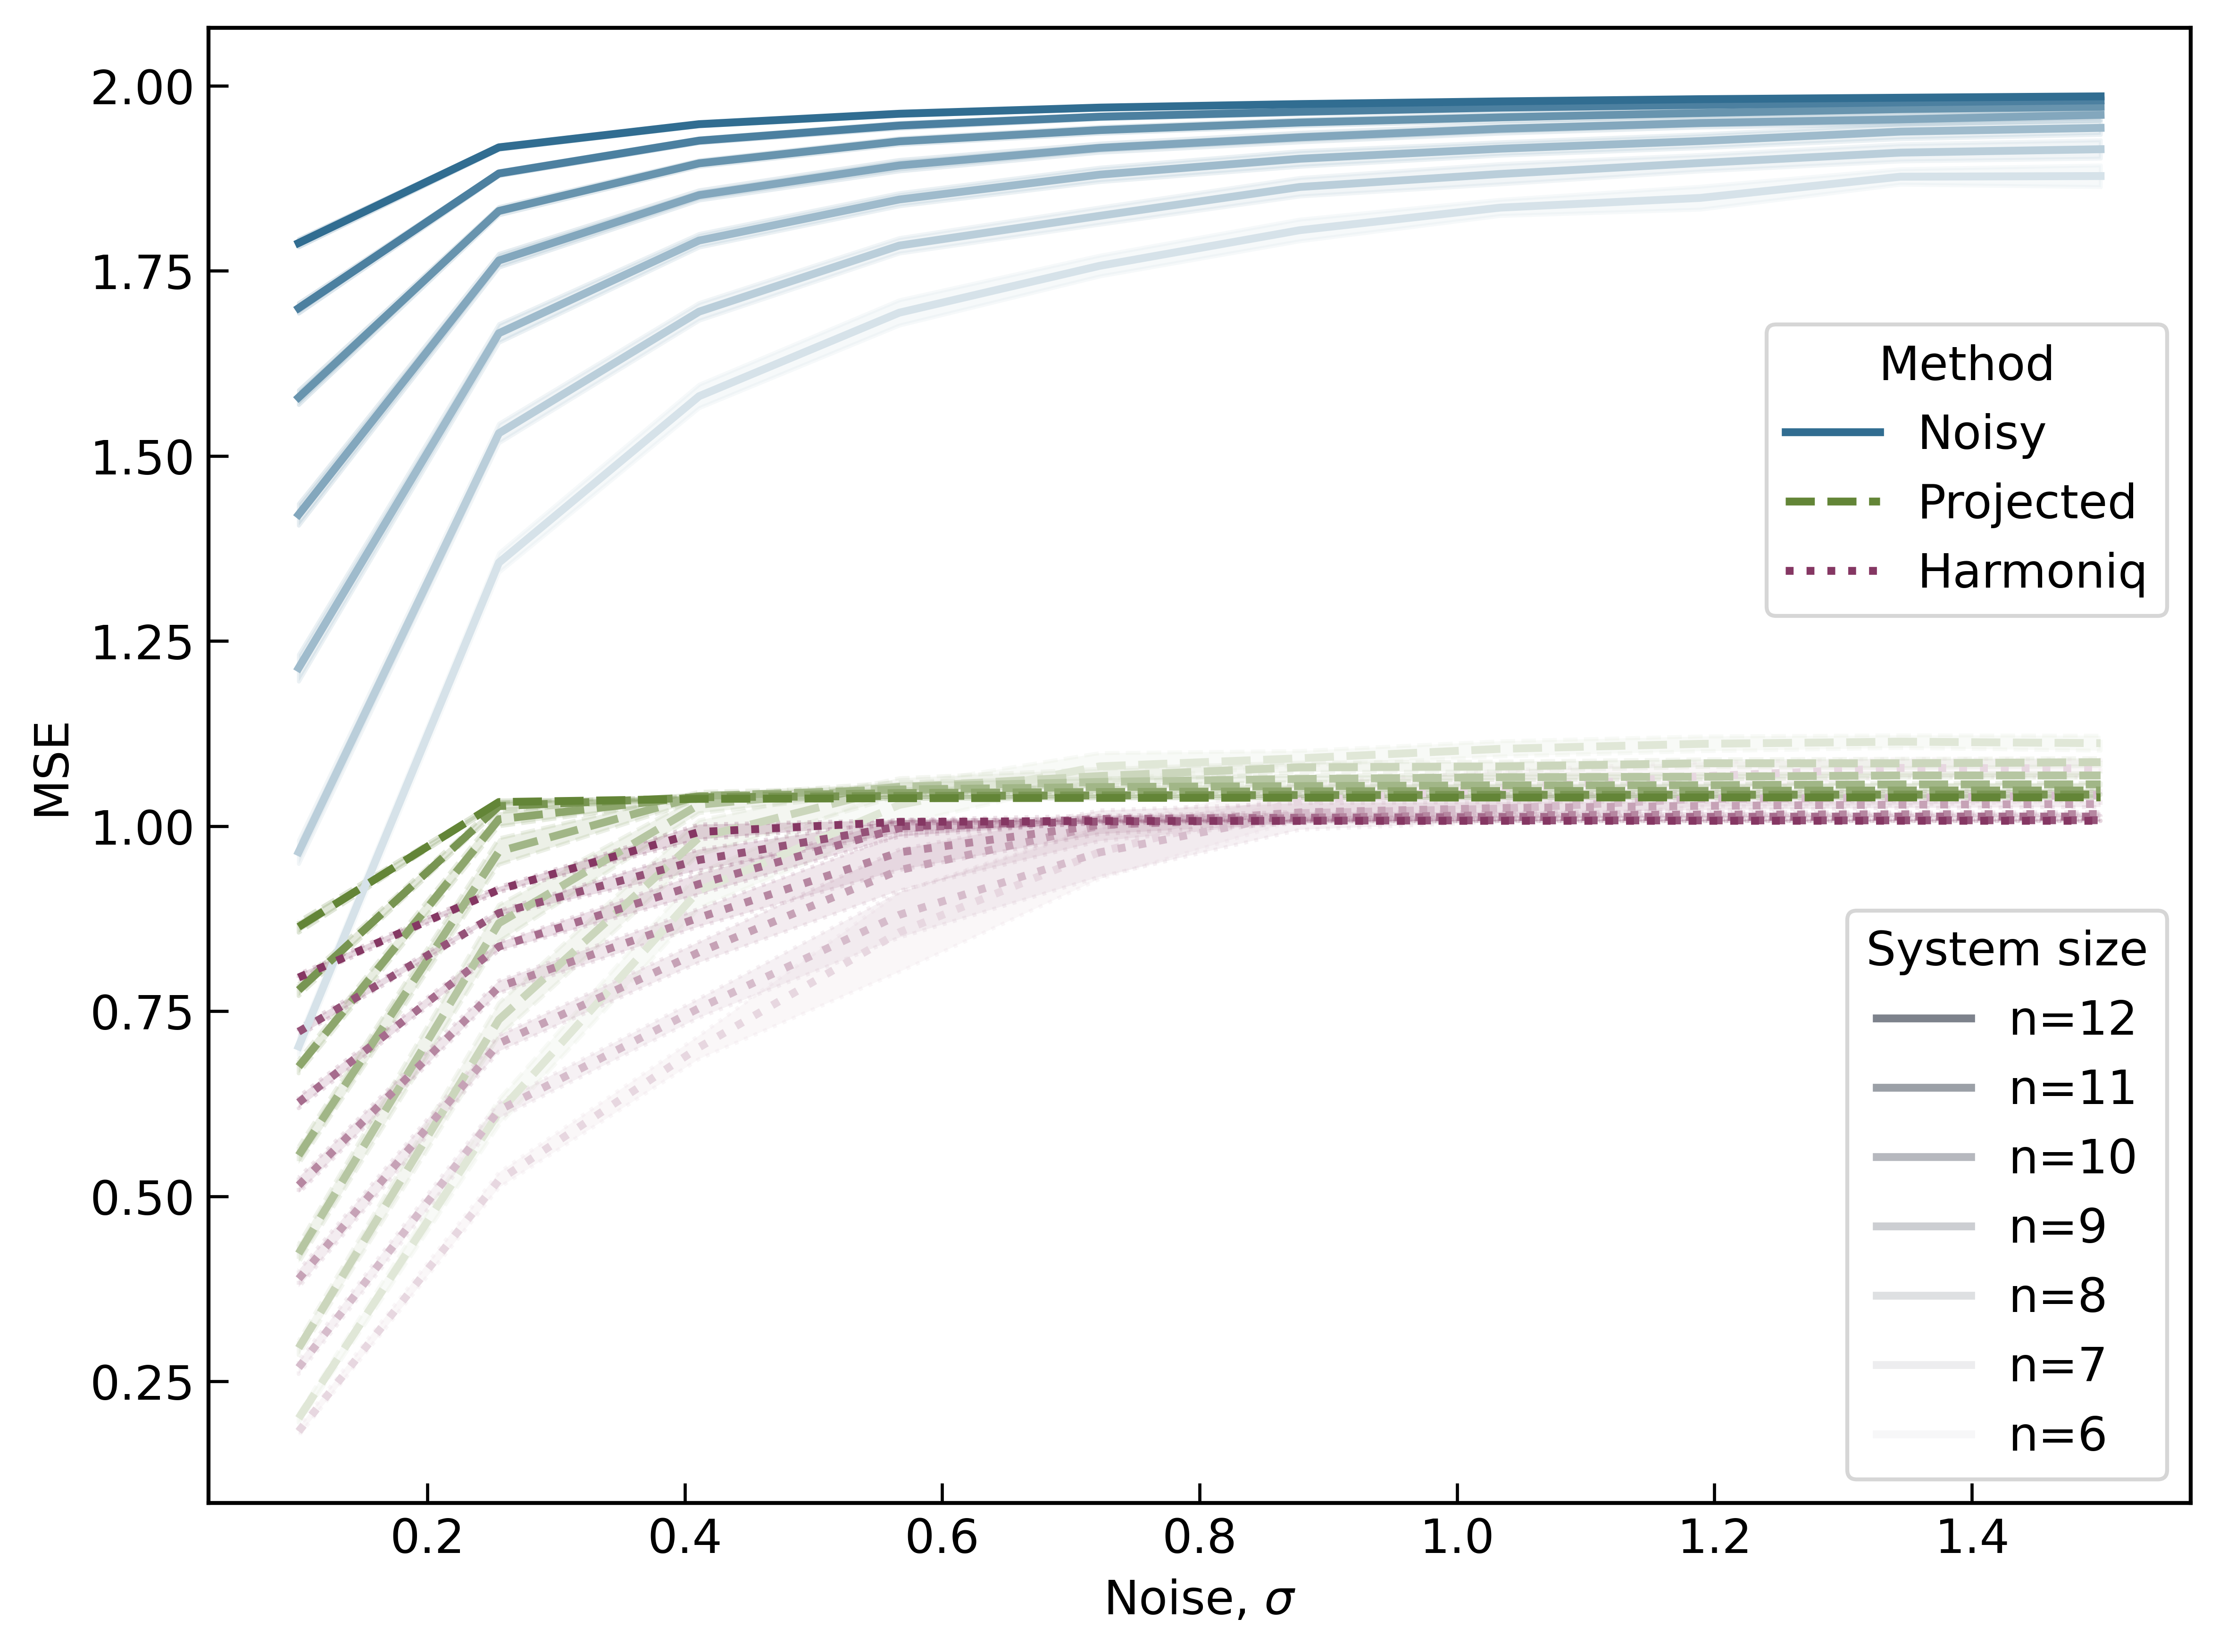

In [11]:
# Parameters
number_of_runs = 10
number_of_batches = 10
n_values = range(6, 13)

alphas = np.linspace(0.3, 1.0, len(n_values))  # lighter → darker

N_reduced = 100

plt.figure(figsize=(8,6))

for i, n in enumerate(n_values):
    if n % 2 == 1:  # if odd
        size_aug = n
    else:
        size_aug = n - 1 # make the window odd

    df = pd.read_csv("Results_noise_experiment/Distances_n_{}_size_aug_{}_runs_{}_batches_{}_N_{}.csv".format(n, size_aug, number_of_runs, number_of_batches, N_reduced))

    x = np.arange(len(df))

    #normalization = np.mean(df["mean_distance_noisy_all"])
    normalization = 1

    mean_noisy = df["mean_distance_noisy_all"]/normalization
    std_noisy = df["std_distance_noisy_all"]/normalization

    mean_denoised = df["mean_distance_denoised_all"]/normalization
    std_denoised = df["std_distance_denoised_all"]/normalization

    mean_aug_denoised = df["mean_distance_aug_denoised_all"]/normalization
    std_aug_denoised = df["std_distance_aug_denoised_all"]/normalization

    color = colors[len(n_values) - 1 - i]
    x = np.linspace(0.1, 1.5, 10)
    plt.plot(x, mean_noisy, linestyle="-", color=Noisycolors[len(n_values) - 1 - i], label=f"n={n}")
    plt.fill_between(x, mean_noisy-std_noisy, mean_noisy+std_noisy, linestyle="-", color=Noisycolors[len(n_values) - 1 - i], alpha=0.2)

    plt.plot(x, mean_denoised, linestyle="--", color=Projectedcolors[len(n_values) - 1 - i], label=f"n={n}")
    plt.fill_between(x, mean_denoised-std_denoised, mean_denoised+std_denoised, linestyle="--", color=Projectedcolors[len(n_values) - 1 - i], alpha=0.2)

    plt.plot(x, mean_aug_denoised, linestyle=":", color=Harmoniqcolors[len(n_values) - 1 - i], label=f"n={n}")
    plt.fill_between(x, mean_aug_denoised-std_aug_denoised, mean_aug_denoised+std_aug_denoised, linestyle=":", color=Harmoniqcolors[len(n_values) - 1 - i], alpha=0.2)


# Add colorbar to show mapping of n → color
from matplotlib.colors import Normalize
norm = Normalize(vmin=6, vmax=13)
plt.xlabel(r'Noise, $\sigma$')
plt.ylabel(r"MSE")
plt.legend()



# First legend:
custom_lines = [
    Line2D([0], [0], color=methodcolors["Noisy"], lw=2, linestyle='-'),
    Line2D([0], [0], color=methodcolors["Projected"], lw=2, linestyle='--'),
    Line2D([0], [0], color=methodcolors["Harmoniq"], lw=2, linestyle=':')
]

legend1 = plt.legend(custom_lines,
                     ["Noisy", "Projected", "Harmoniq"],
                     title="Method",
                     loc="center right", bbox_to_anchor=(1, 0.7))

plt.gca().add_artist(legend1)

# Second legend:

alpha_lines = [
    Line2D([0], [0], color=c, lw=2, alpha=a)
    for c, a in zip(colors, alphas[::-1])
]
plt.legend(alpha_lines,
           [
               f"n={n_values[6]}",
               f"n={n_values[5]}",
               f"n={n_values[4]}",
               f"n={n_values[3]}",
               f"n={n_values[2]}",
               f"n={n_values[1]}",
               f"n={n_values[0]}"
            ],
           title="System size",
           loc="lower right")


plt.tight_layout()
#plt.savefig("Plots_10x10/mse_all_sigmas_jadwiga_colors.png".format(n), dpi=600)
plt.show()
